# Electrolyser efficiency analysis
This python code will cover the Electrolyser efficiencies for various tests.

### Setting up project and running all rate files
Here the project is set up, and data is imported. The performance of the electrolyser is also measured

In [ ]:
""
"  This Code is created by Daan Schat - 5169801 - TU Delft Master Student SET"
"  for the Green Village energy hub project"
""

# Setting up the environment:
import matplotlib.pyplot as plt
import random
import pandas as pd
import numpy as np
import os
import chardet
from IPython.display import display, Javascript

# Variables & Constants:
LHV_H2 = 120000000 # J/kg
HHV_H2 = 142000000 # J/kg
MolarVolume = 22.414 # L/mol.
MolarMass = 2.016 # g/mol
H2Density = MolarMass/MolarVolume # g/L

files = ["Electrolyser 60.csv", "Electrolyser 70.csv", "Electrolyser 80.csv", "Electrolyser 90.csv", "Electrolyser 100.csv"]
Efficiencies = []
Rates = []
compRates = []
flowRates = []

for file in files:
    subfolder = "Joel Electrolyser data"
    df = pd.read_csv(file, sep=',', skiprows=1)
    Efficiency, Rate, compRate, flowRate = Electrolyserdata(df)
    Efficiencies.append(Efficiency)
    Rates.append(Rate)
    compRates.append(compRate)
    flowRates.append(flowRate)



In [ ]:
def Electrolyserdata(df):
    
    
    df = df.rename(columns={'Electrolyser Power (W)': 'Total Electrolyser Power (W)'})
    df['Hydrogen Flow Rate (NL/h)'] = df['Hydrogen Flow Rate (NL/h)'].interpolate(method='linear')
    df['Electrolyser Production Rate (%)'] = df['Electrolyser Production Rate (%)'].interpolate(method='linear')
    df['Total Electrolyser Power (W)'] = df['Total Electrolyser Power (W)'].interpolate(method='linear')
    df['Compressor Power (W)'] = df['Compressor Power (W)'].interpolate(method='linear')
    df['Electrolyser Stack Voltage (V)'] = df['Electrolyser Stack Voltage (V)'].interpolate(method='linear')
    df['Electrolyser Stack Current (A)'] = df['Electrolyser Stack Current (A)'].interpolate(method='linear')
    df['Electrolyser Power (W)'] = df['Electrolyser Stack Voltage (V)'] * df['Electrolyser Stack Current (A)']

    FuelCellEff = 0.5 # Set Fuel cell efficiency here
    rate = df.iloc[0]['Electrolyser Production Rate (%)']
    df['Time'] = pd.to_datetime(df['Time'])
    Time = pd.to_datetime(df['Time'])
    time_numeric = (Time - Time.iloc[0]).dt.total_seconds().astype(int)
    print()
    print()
    print('----------------------------------------------------------------------------------------------------')
    print(f'--------------------------- Electrolyser operating at {rate}% of full power --------------------------')
    print('----------------------------------------------------------------------------------------------------')

    
    # Total Electrolyser Power over Time
    values = df['Total Electrolyser Power (W)']
    positive_values = np.where(values > 0, values, 0)
    TotElecEnergy = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values

    plt.figure(figsize=(10, 6))
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Energy used (kWh): {TotElecEnergy:.3f}', color='gray')
    plt.plot(df['Time'], df['Total Electrolyser Power (W)'], label='Total Electrolyser Power (W)', color='gray')
    plt.title(f'Total Electrolyser Power Over Time, At {rate}% Of Operational Power')
    plt.xlabel('Time')
    plt.ylabel('Total Electrolyser Power (W)')
    plt.xlim(df['Time'].min(), df['Time'].max())
    plt.ylim(0, df['Total Electrolyser Power (W)'].max()*1.2)
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"figures/Total Electrolyser Power - {rate}.png")
    plt.show()

    
    
    # Plot Compressor Power over Time
    values = df['Compressor Power (W)']
    positive_values = np.where(values > 0, values, 0)
    CompEnergy = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values
    compRate = values.mean()
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Energy used (kWh): {CompEnergy:.3f}', color='r')

    plt.plot(df['Time'], df['Compressor Power (W)'], label='Compressor Power (W)', color='r')
    plt.title(f'Compressor Power Over time, At {rate}% Of Operational Power')
    plt.xlabel('Time')
    plt.ylabel('Compressor Power (W)')
    plt.xlim(df['Time'].min(), df['Time'].max())
    plt.ylim(0, df['Compressor Power (W)'].max()*1.2)
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"figures/Compressor Power - {rate}.png")
    plt.show()

    
    
    # Plot Electrolyser stack Power over Time
    values = df['Electrolyser Power (W)']
    positive_values = np.where(values > 0, values, 0)
    ElecEnergy = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values

    plt.figure(figsize=(10, 6))
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Energy used (kWh): {ElecEnergy:.3f}', color='c')
    plt.plot(df['Time'], df['Electrolyser Power (W)'], label='Electrolyser stack Power (W)', color='c')
    plt.title(f'Electrolyser Stack Power Over Time, At {rate}% Of Operational Power')
    plt.xlabel('Time')
    plt.ylabel('Electrolyser Power (W)')
    plt.xlim(df['Time'].min(), df['Time'].max())
    plt.ylim(0, df['Electrolyser Power (W)'].max()*1.2)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"figures/Electrolyser Stack Power - {rate}.png")
    plt.show()
    
    
    
    # Plot Hydrogen Flow Rate
    values = df['Hydrogen Flow Rate (NL/h)']
    flowRate = values.mean()
    time_numeric = (Time - Time.iloc[0]).dt.total_seconds().astype(int)
    positive_values = np.where(values > 0, values, 0)
    H2pos = np.trapz(values, time_numeric) # Perform integration
    H2Prod = H2Density*H2pos/(3600*1000) # H2 flow to kg
    EnergyH2 = LHV_H2*H2Prod/(3600*1000) # H2 flow to kWh(chem) (of H2)
    
    plt.figure(figsize=(10, 6))
    plt.plot(Time, values, label='Hydrogen production')
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Hydrogen produced: {H2Prod:.3f} kg', color='blue')
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Energy content: {EnergyH2:.3f} kWh', color='blue')
    
    plt.title('Hydrogen Production Over Time')
    plt.xlabel('Time')
    plt.ylabel('Hydrogen Flow [NL/h]')
    plt.xlim(df['Time'].min(), df['Time'].max())
    plt.ylim(0, df['Hydrogen Flow Rate (NL/h)'].max()*1.2)
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/Hydrogen Flow Rate - {rate}.png")
    plt.show()

    print()
    print(f"Mean Stack power at {rate}% {df['Electrolyser Power (W)'].mean():.2f} [W] ")
    print(f"Mean Total electrolyser power at {rate}% {df['Total Electrolyser Power (W)'].mean():.2f} [W] ")
    print(f"Mean Compressor power at {rate}% {df['Compressor Power (W)'].mean():.2f} [W] ")
    print(f"Mean Hydrogen flow rate at {rate}% {df['Hydrogen Flow Rate (NL/h)'].mean():.2f} [NL/h] ")
    print()
    print()
    print(f"Compressor energy at {rate}% {CompEnergy:.2f} [kWh] ")
    print(f"Electrolyser Stack energy at {rate}% {ElecEnergy:.2f} [kWh] ")
    print(f"Total Electrolyser energy at {rate}% {TotElecEnergy:.2f} [kWh] ")
    print(f"Total Hydrogen energy produced at {rate}% {EnergyH2:.2f} [kWh] ")
    print()
    print()
    print(f"Total efficiency of electrolyser stack running at {rate}% of nominal power: {100*EnergyH2/ElecEnergy:.2f}% ")
    print(f"Total efficiency of electrolyser running at {rate}% of nominal power: {100*EnergyH2/TotElecEnergy:.2f}% ")
    print(f"Total efficiency of electrolyser & compressor running at {rate}% of nominal power: {100*EnergyH2/(TotElecEnergy+CompEnergy):.2f}% ")
    print(f"Total efficiency of electrolyser, compressor & fuel cell running at {rate}% of nominal power: {FuelCellEff*100*EnergyH2/(TotElecEnergy+CompEnergy):.2f}% ")
    print()
    print('----------------------------------------------------------------------------------------------------')

    return 100*EnergyH2/(TotElecEnergy+CompEnergy), rate, compRate, flowRate

### Efficiency & Compressor plot
Plotting the efficiency of each rates.
Also the compressor power based on operating rate is determined.

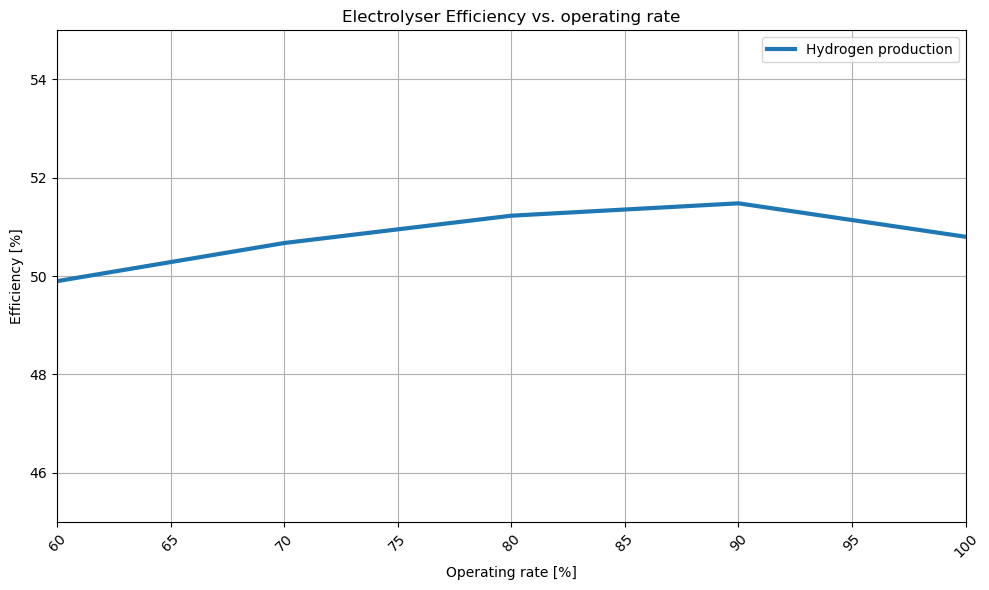

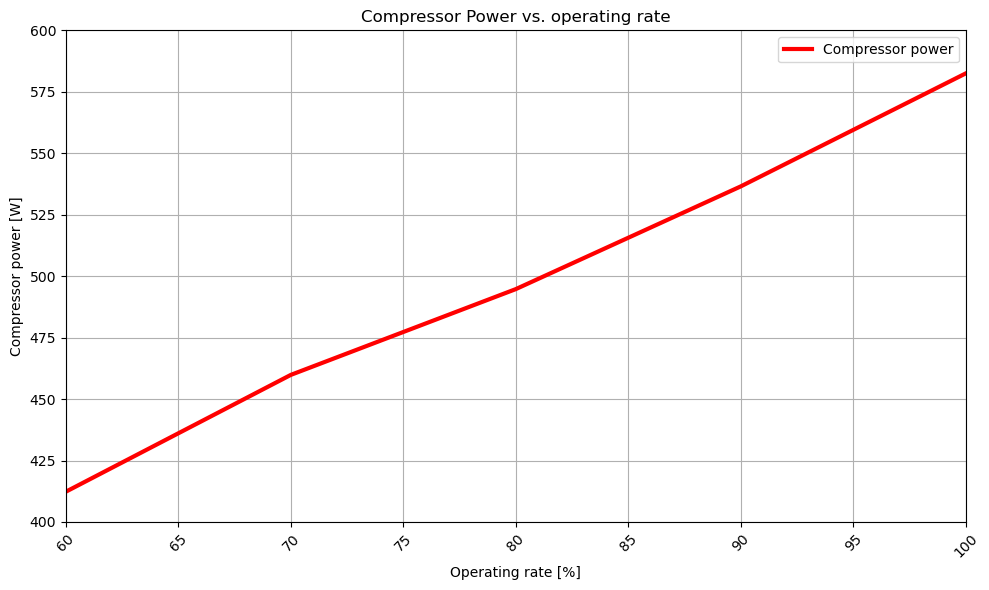

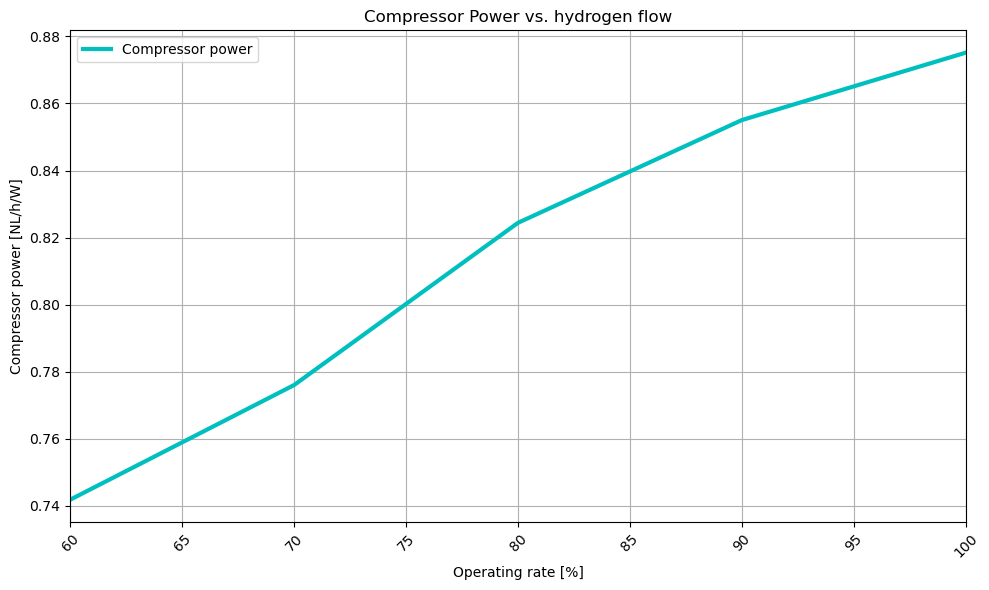



Compressor min: 0.7418831360482699
Compressor max: 0.8751474491652587
Compressor efficiency increase: 17.96


In [76]:
plt.figure(figsize=(10, 6))
plt.plot(Rates,Efficiencies, linewidth = 3, label='Hydrogen production')
    
plt.title('Electrolyser Efficiency vs. operating rate')
plt.xlabel('Operating rate [%]')
plt.ylabel('Efficiency [%]')
plt.xlim(60, 100)
plt.ylim(45, 55)
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig(f"figures/Electrolyser efficiency vs rate.png")
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(Rates,compRates, linewidth = 3, label='Compressor power', color = 'r')
plt.title('Compressor Power vs. operating rate')
plt.xlabel('Operating rate [%]')
plt.ylabel('Compressor power [W]')
plt.xlim(60, 100)
plt.ylim(400, 600)
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig(f"figures/Compressor power vs rate.png")
plt.show()

combRate = np.divide(flowRates,compRates)
plt.figure(figsize=(10, 6))
plt.plot(Rates, combRate, linewidth = 3, label='Compressor power', color = 'c')
plt.title('Compressor Power vs. hydrogen flow')
plt.xlabel('Operating rate [%]')
plt.ylabel('Compressor power [NL/h/W]')
plt.xlim(60, 100)

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig(f"figures/Compressor power vs hydrogen flow.png")
plt.show()

print()
print()
print(f"Compressor min: {combRate.min()}")
print(f"Compressor max: {combRate.max()}")
print(f"Compressor efficiency increase: {100*(combRate.max()-combRate.min())/combRate.min():.2f}")

### Electrolyser following PV power (cloudy & Sunny)
This part of the code will cover the electrolyser following the PV inverter output data. This is done for both a sunny day, and a cloudy day.



----------------------------------------------------------------------------------------------------
---------------------------- Electrolyser operating at Sunny condition -----------------------------
----------------------------------------------------------------------------------------------------


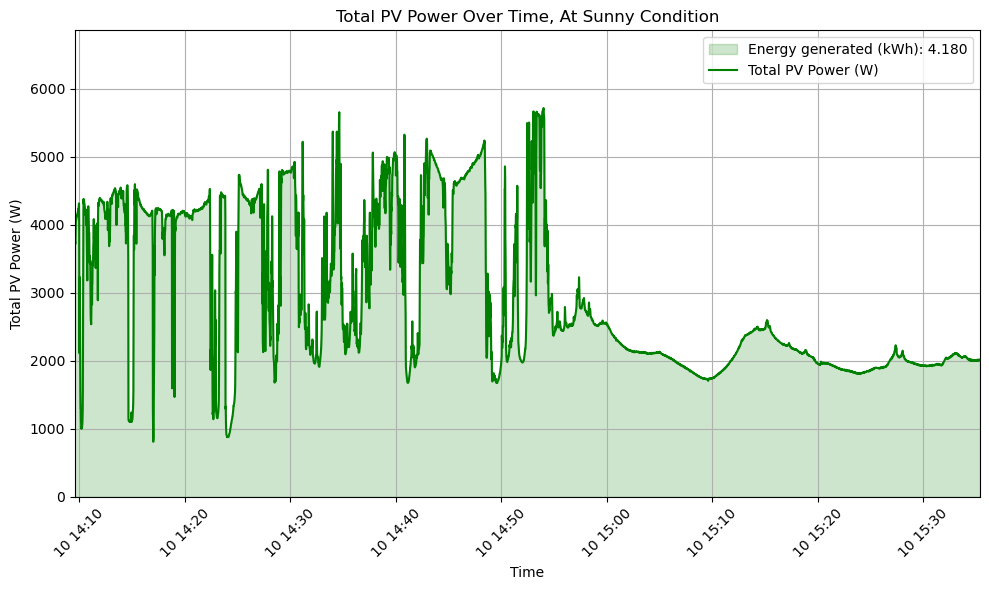

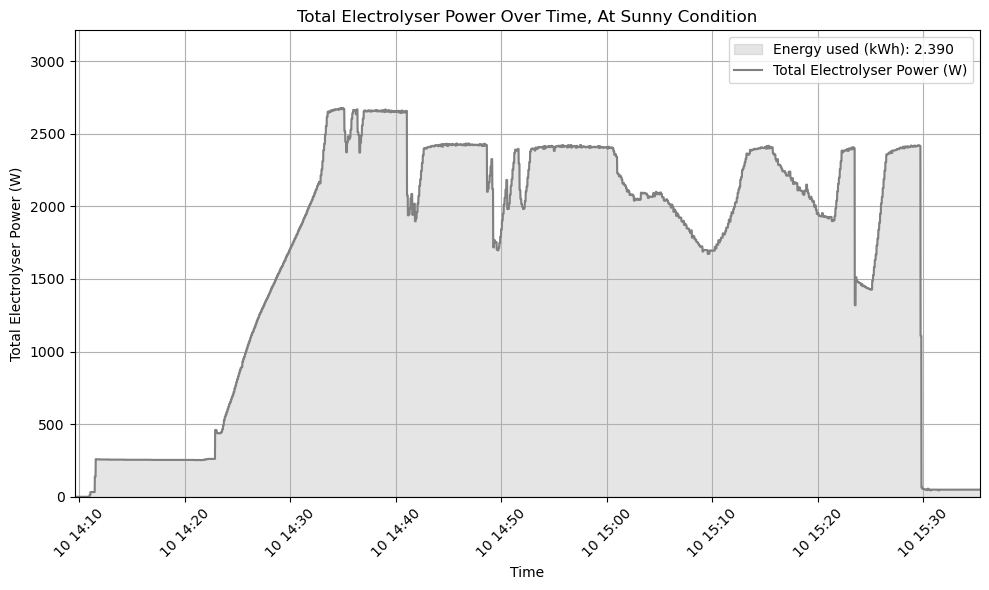

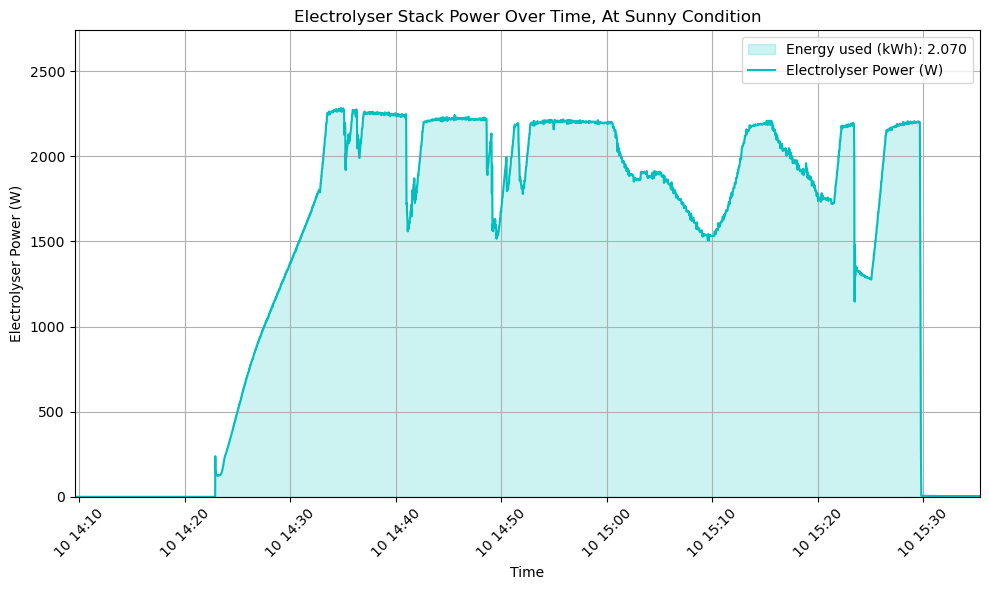

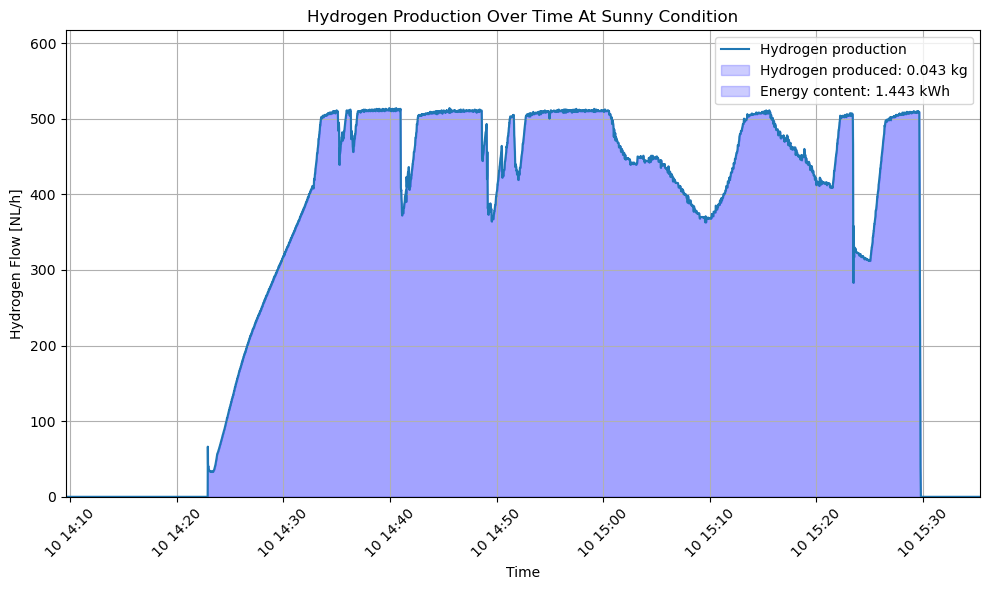


Total efficiency of electrolyser stack running at Sunny condition: 69.68% 
Total efficiency of electrolyser running at Sunny condition: 60.37% 

----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------
---------------------------- Electrolyser operating at Cloudy condition -----------------------------
----------------------------------------------------------------------------------------------------


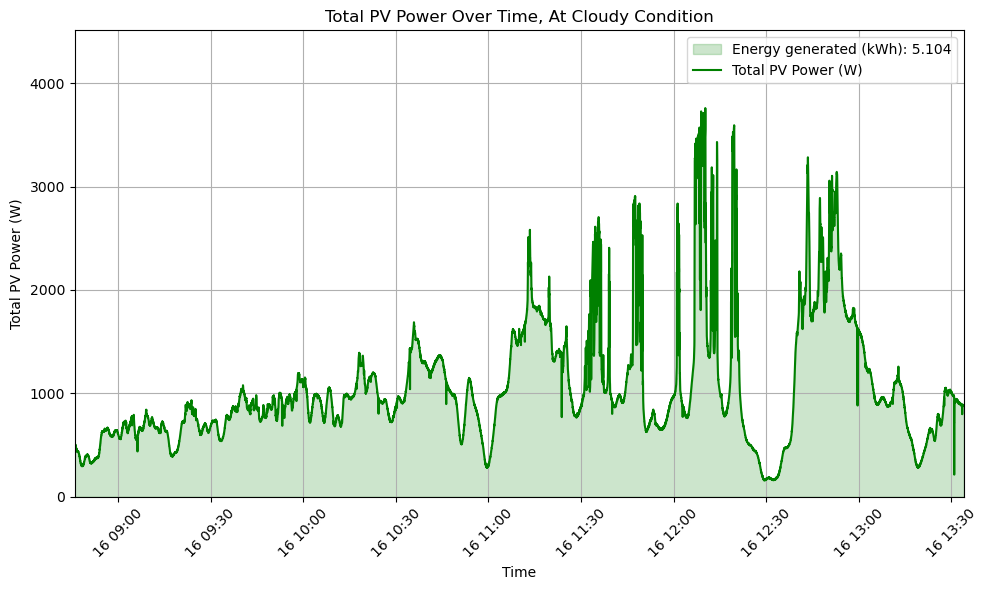

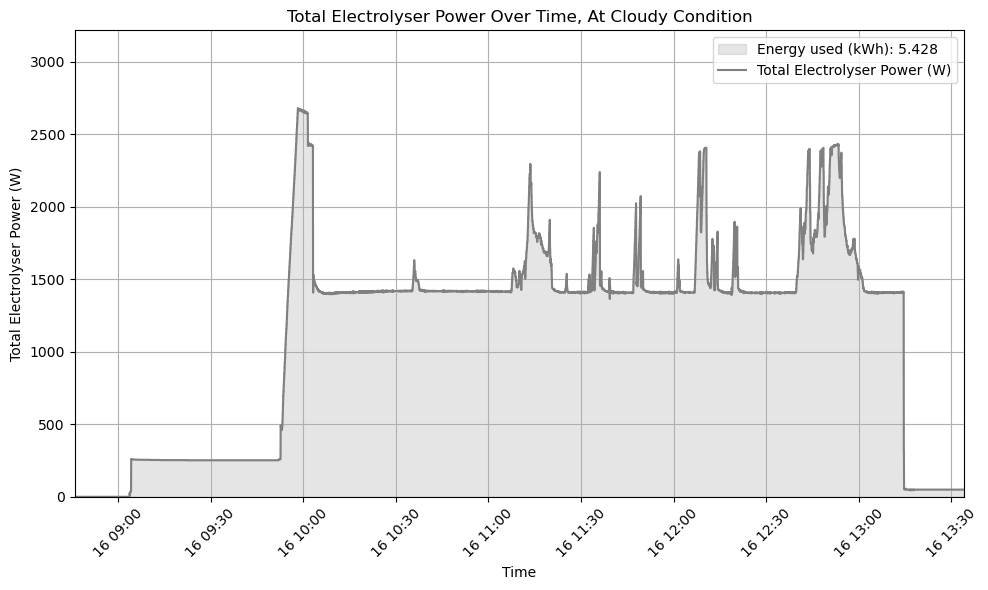

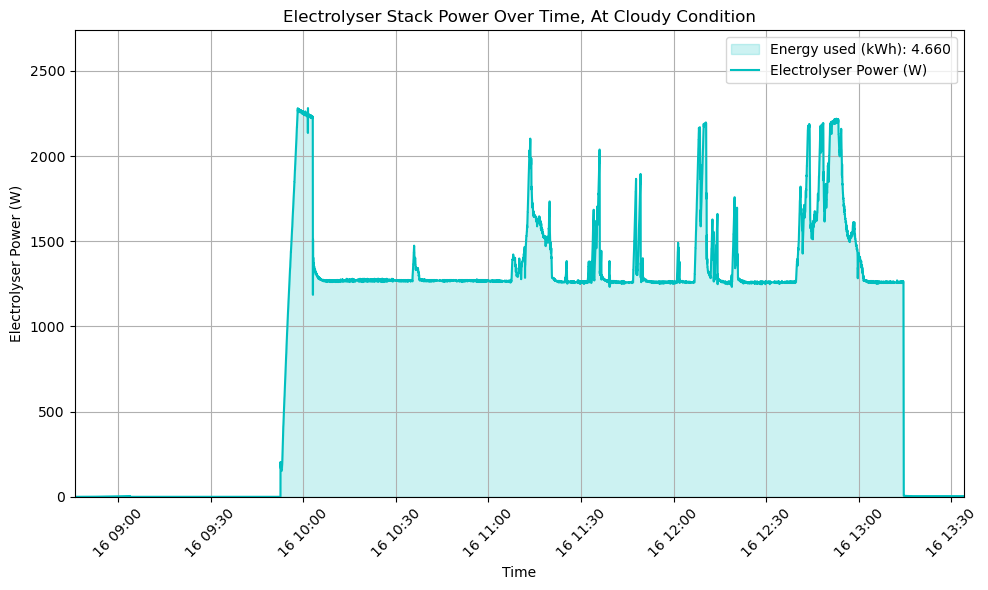

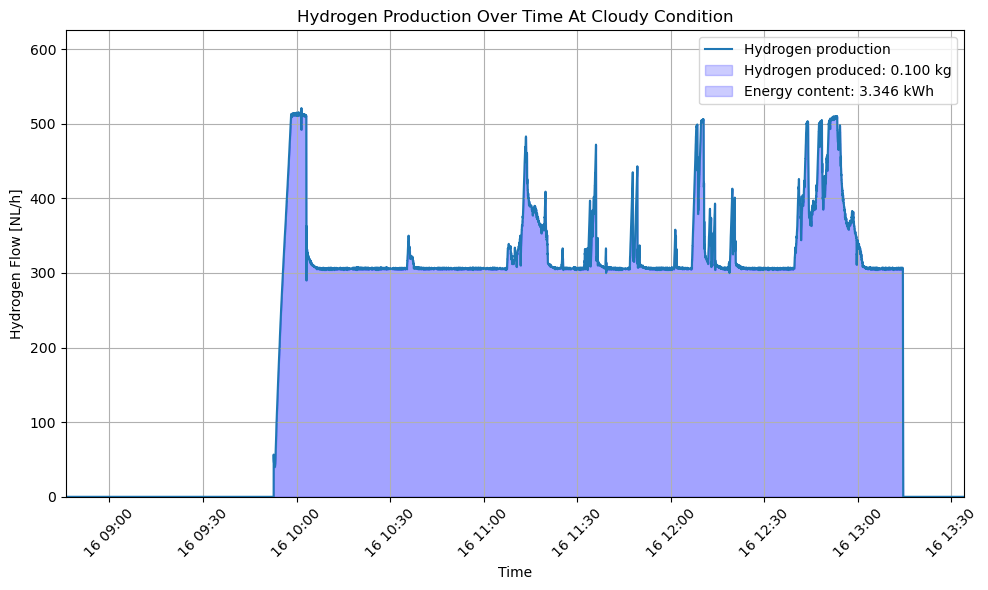


Total efficiency of electrolyser stack running at Cloudy condition: 71.81% 
Total efficiency of electrolyser running at Cloudy condition: 61.65% 

----------------------------------------------------------------------------------------------------


In [83]:

files = ["Electrolyser Follow PV Power - Sunny.csv","Electrolyser Follow PV Power - Cloudy.csv"]

Efficiencies = []
Rates = []

for file in files:
    subfolder = "Joel Electrolyser data"
    df = pd.read_csv(file, sep=',', skiprows=1)
    name = os.path.splitext(os.path.basename(file))[0]  # Remove file extension
    name = name.split(' - ')[-1]  # Split by " - " and take the last part
    Efficiency, Rate = PV_electrolyser(df, name)
    Efficiencies.append(Efficiency)
    Rates.append(Rate)
    


In [16]:
def PV_electrolyser(df, name):
    
    
    df = df.rename(columns={'Electrolyser Power (W)': 'Total Electrolyser Power (W)'})
    columns_to_fill = ['Total Electrolyser Power (W)', 'Electrolyser Production Rate (%)', 'Hydrogen Flow Rate (NL/h)','Electrolyser Stack Voltage (V)','Electrolyser Stack Current (A)',]  # Specify your columns here (e.g., 'A', 'B')
    df.loc[:df.first_valid_index(), columns_to_fill] = df.loc[:df.first_valid_index(), columns_to_fill].fillna(0)
    df.loc[df.last_valid_index() + 1:, columns_to_fill] = df.loc[df.last_valid_index() + 1:, columns_to_fill].fillna(0)

    df['Hydrogen Flow Rate (NL/h)'] = df['Hydrogen Flow Rate (NL/h)'].interpolate(method='linear')
    df['Electrolyser Production Rate (%)'] = df['Electrolyser Production Rate (%)'].interpolate(method='linear')
    df['Total Electrolyser Power (W)'] = df['Total Electrolyser Power (W)'].interpolate(method='linear')
    df['Electrolyser Stack Voltage (V)'] = df['Electrolyser Stack Voltage (V)'].interpolate(method='linear')
    df['Electrolyser Stack Current (A)'] = df['Electrolyser Stack Current (A)'].interpolate(method='linear')
    df['Container PV Power (W)'] = df['Container PV Power (W)'].interpolate(method='linear')
    df['Electrolyser Power (W)'] = df['Electrolyser Stack Voltage (V)'] * df['Electrolyser Stack Current (A)']

    FuelCellEff = 0.5 # Set Fuel cell efficiency here
    df['Time'] = pd.to_datetime(df['Time'])
    Time = pd.to_datetime(df['Time'])
    time_numeric = (Time - Time.iloc[0]).dt.total_seconds().astype(int)
    print()
    print()
    print('----------------------------------------------------------------------------------------------------')
    print(f'---------------------------- Electrolyser operating at {name} condition -----------------------------')
    print('----------------------------------------------------------------------------------------------------')

    
    # Total PV Power over Time
    values = df['Container PV Power (W)']
    positive_values = np.where(values > 0, values, 0)
    TotPVEnergy = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values

    plt.figure(figsize=(10, 6))
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Energy generated (kWh): {TotPVEnergy:.3f}', color='g')
    plt.plot(df['Time'], df['Container PV Power (W)'], label='Total PV Power (W)', color='g')
    plt.title(f'Total PV Power Over Time, At {name} Condition')
    plt.xlabel('Time')
    plt.ylabel('Total PV Power (W)')
    plt.xlim(df['Time'].min(), df['Time'].max())
    plt.ylim(0, df['Container PV Power (W)'].max()*1.2)
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"figures/Total PV Power - {name}.png")
    plt.show()
    
    
    # Total Electrolyser Power over Time
    values = df['Total Electrolyser Power (W)']
    positive_values = np.where(values > 0, values, 0)
    TotElecEnergy = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values

    plt.figure(figsize=(10, 6))
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Energy used (kWh): {TotElecEnergy:.3f}', color='gray')
    plt.plot(df['Time'], df['Total Electrolyser Power (W)'], label='Total Electrolyser Power (W)', color='gray')
    plt.title(f'Total Electrolyser Power Over Time, At {name} Condition')
    plt.xlabel('Time')
    plt.ylabel('Total Electrolyser Power (W)')
    plt.xlim(df['Time'].min(), df['Time'].max())
    plt.ylim(0, df['Total Electrolyser Power (W)'].max()*1.2)
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"figures/Total Electrolyser Power - {name}.png")
    plt.show()

      
    
    # Plot Electrolyser Power over Time
    values = df['Electrolyser Power (W)']
    positive_values = np.where(values > 0, values, 0)
    ElecEnergy = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values

    plt.figure(figsize=(10, 6))
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Energy used (kWh): {ElecEnergy:.3f}', color='c')
    plt.plot(df['Time'], df['Electrolyser Power (W)'], label='Electrolyser Power (W)', color='c')
    plt.title(f'Electrolyser Stack Power Over Time, At {name} Condition')
    plt.xlabel('Time')
    plt.ylabel('Electrolyser Power (W)')
    plt.xlim(df['Time'].min(), df['Time'].max())
    plt.ylim(0, df['Electrolyser Power (W)'].max()*1.2)
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"figures/Electrolyser Stack Power - {name}.png")
    plt.show()
    
    
    
    # Plot Hydrogen Flow Rate
    values = df['Hydrogen Flow Rate (NL/h)']
    time_numeric = (Time - Time.iloc[0]).dt.total_seconds().astype(int)
    positive_values = np.where(values > 0, values, 0)
    H2pos = np.trapz(values, time_numeric) # Perform integration
    H2Prod = H2Density*H2pos/(3600*1000) # H2 flow to kg
    EnergyH2 = LHV_H2*H2Prod/(3600*1000) # H2 flow to kWh(chem) (of H2)
    
    plt.figure(figsize=(10, 6))
    plt.plot(Time, values, label='Hydrogen production')
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Hydrogen produced: {H2Prod:.3f} kg', color='blue')
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Energy content: {EnergyH2:.3f} kWh', color='blue')
    
    plt.title(f'Hydrogen Production Over Time At {name} Condition')
    plt.xlabel('Time')
    plt.ylabel('Hydrogen Flow [NL/h]')
    plt.xlim(df['Time'].min(), df['Time'].max())
    plt.ylim(0, df['Hydrogen Flow Rate (NL/h)'].max()*1.2)
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/Hydrogen Flow Rate - {name}.png")
    plt.show()
    
    print()
    print(f"Total efficiency of electrolyser stack running at {name} condition: {100*EnergyH2/ElecEnergy:.2f}% ")
    print(f"Total efficiency of electrolyser running at {name} condition: {100*EnergyH2/TotElecEnergy:.2f}% ")

    print()
    print('----------------------------------------------------------------------------------------------------')

    return 100*EnergyH2/(TotElecEnergy), name

### Starting and stopping
Looking more closely to the data, it can be noticed how the PV power is already high again, but the electrolyser needs to catch up, which takes about 1:30 min.



----------------------------------------------------------------------------------------------------
---------------------------- Electrolyser operating at Cloudy condition -----------------------------
----------------------------------------------------------------------------------------------------


/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_17036/3416325648.py:12: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  vlines = pd.to_datetime(vlines)


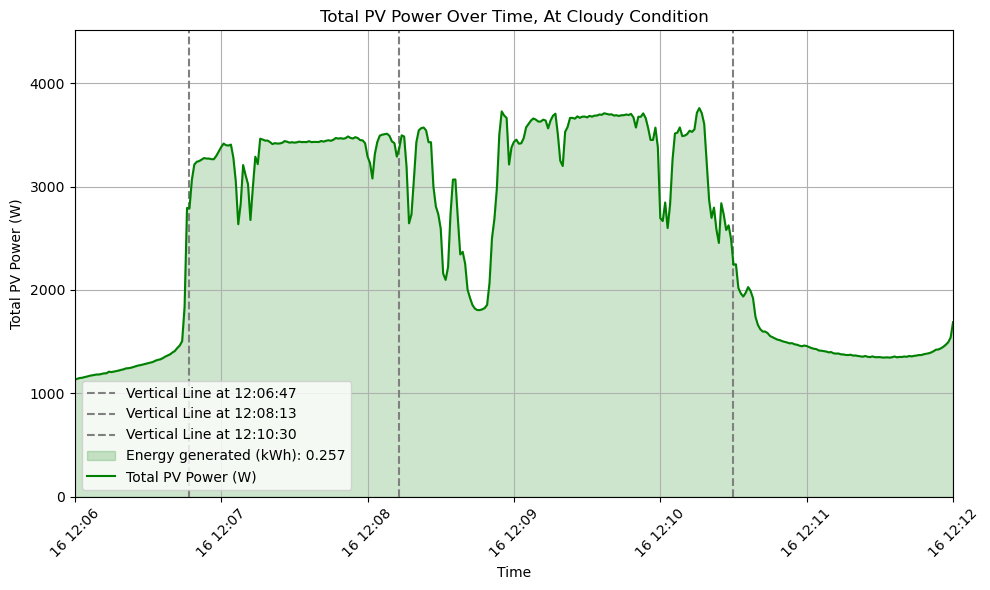

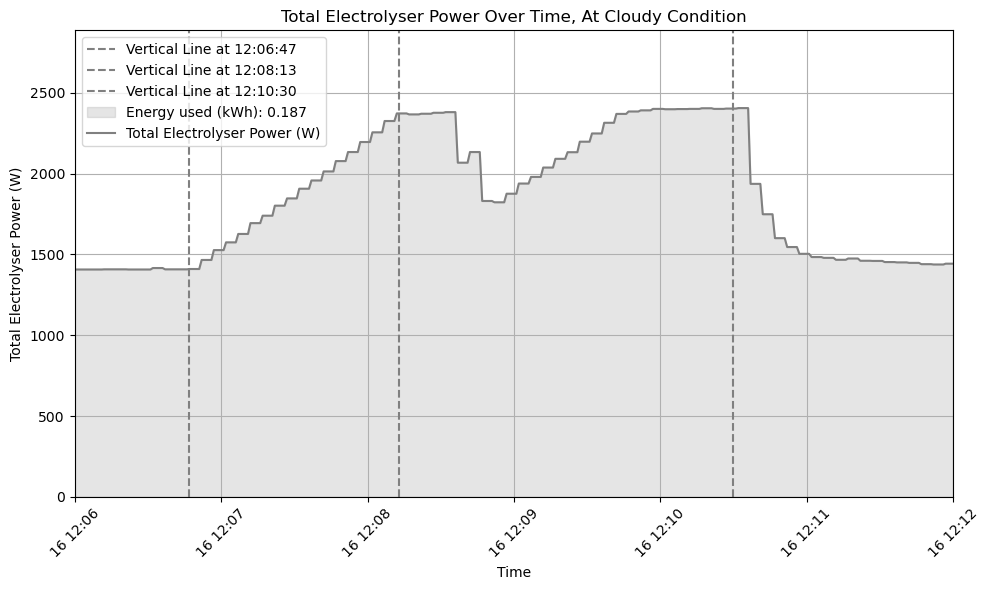

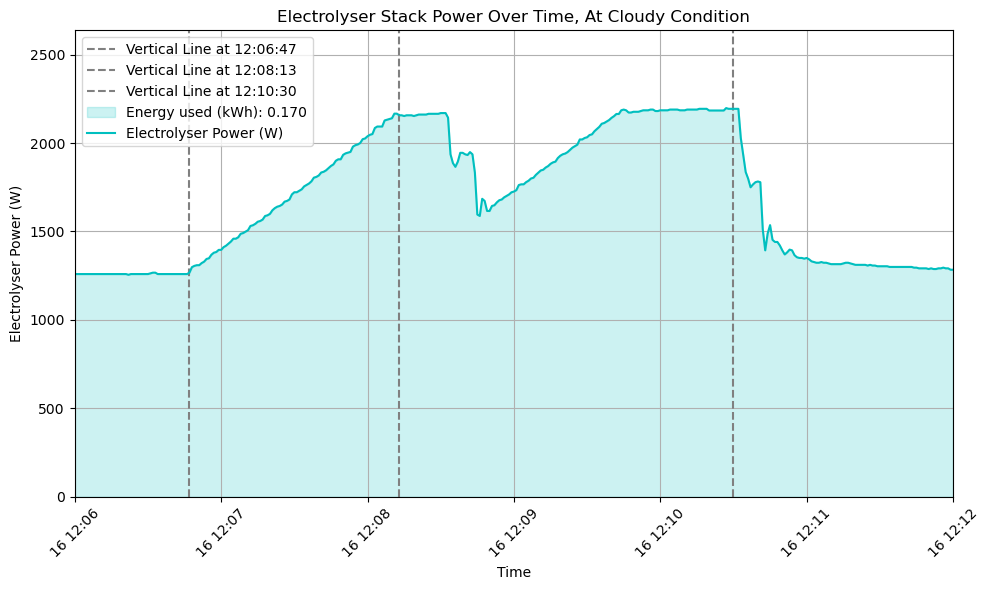

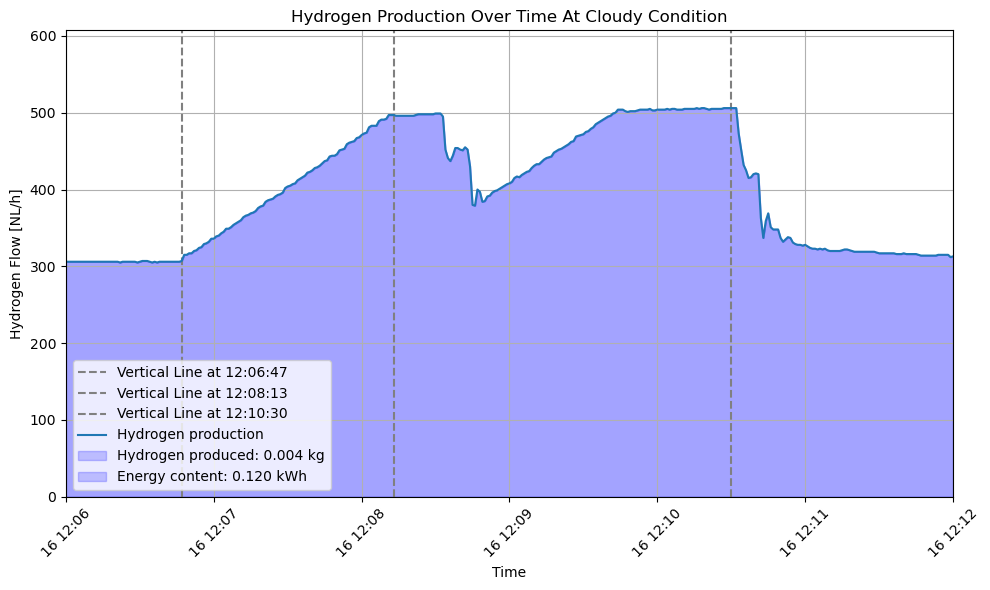

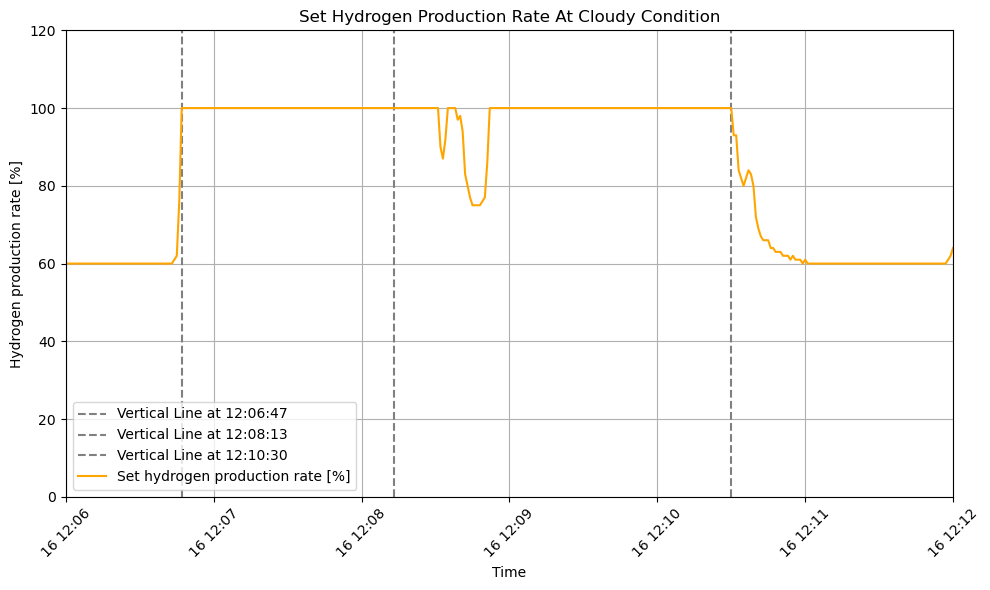


Total efficiency of electrolyser stack running at Cloudy condition: 70.71% 
Total efficiency of electrolyser running at Cloudy condition: 64.02% 

----------------------------------------------------------------------------------------------------


In [81]:

files = ["Electrolyser Follow PV Power - Cloudy.csv"]

Efficiencies = []
Rates = []

for file in files:
    subfolder = "Joel Electrolyser data"
    df = pd.read_csv(file, sep=',', skiprows=1)
    name = os.path.splitext(os.path.basename(file))[0]  # Remove file extension
    name = name.split(' - ')[-1]  # Split by " - " and take the last part
    Efficiency, Rate = closelook(df, name)
    

In [20]:
def closelook(df, name):
    
    
    FuelCellEff = 0.5 # Set Fuel cell efficiency here
    
    df = df.rename(columns={'Electrolyser Power (W)': 'Total Electrolyser Power (W)'})
    columns_to_fill = ['Total Electrolyser Power (W)', 'Electrolyser Production Rate (%)', 'Hydrogen Flow Rate (NL/h)','Electrolyser Stack Voltage (V)','Electrolyser Stack Current (A)',]  # Specify your columns here (e.g., 'A', 'B')
    df.loc[:df.first_valid_index(), columns_to_fill] = df.loc[:df.first_valid_index(), columns_to_fill].fillna(0)
    df.loc[df.last_valid_index() + 1:, columns_to_fill] = df.loc[df.last_valid_index() + 1:, columns_to_fill].fillna(0)

    vlines = ['16-07-2024 12:06:47', '16-07-2024 12:08:13', '16-07-2024 12:10:30'] # Start of electrolyser winding up, Electrolyser full power,
    vlines = pd.to_datetime(vlines)

    df['Hydrogen Flow Rate (NL/h)'] = df['Hydrogen Flow Rate (NL/h)'].interpolate(method='linear')
    df['Electrolyser Production Rate (%)'] = df['Electrolyser Production Rate (%)'].interpolate(method='linear')
    df['Total Electrolyser Power (W)'] = df['Total Electrolyser Power (W)'].interpolate(method='linear')
    df['Electrolyser Stack Voltage (V)'] = df['Electrolyser Stack Voltage (V)'].interpolate(method='linear')
    df['Electrolyser Stack Current (A)'] = df['Electrolyser Stack Current (A)'].interpolate(method='linear')
    df['Container PV Power (W)'] = df['Container PV Power (W)'].interpolate(method='linear')
    df['Electrolyser Power (W)'] = df['Electrolyser Stack Voltage (V)'] * df['Electrolyser Stack Current (A)']


    df['Time'] = pd.to_datetime(df['Time'])
    start_time = '16-07-2024 12:06:00'  # replace with your start time
    end_time = '16-07-2024 12:12:00'    # replace with your end time
    df = df[(df['Time'] >= start_time) & (df['Time'] <= end_time)]
    
    Time = pd.to_datetime(df['Time'])
    time_numeric = (Time - Time.iloc[0]).dt.total_seconds().astype(int)

    
    print()
    print()
    print('----------------------------------------------------------------------------------------------------')
    print(f'---------------------------- Electrolyser operating at {name} condition -----------------------------')
    print('----------------------------------------------------------------------------------------------------')

    
    # Total PV Power over Time
    values = df['Container PV Power (W)']
    positive_values = np.where(values > 0, values, 0)
    TotPVEnergy = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values

    plt.figure(figsize=(10, 6))
    for vline in vlines:
        plt.axvline(x=vline, color='gray', linestyle='--', label=f'Vertical Line at {vline.strftime("%H:%M:%S")}')
    
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Energy generated (kWh): {TotPVEnergy:.3f}', color='g')
    plt.plot(df['Time'], df['Container PV Power (W)'], label='Total PV Power (W)', color='g')
    plt.title(f'Total PV Power Over Time, At {name} Condition')
    plt.xlabel('Time')
    plt.ylabel('Total PV Power (W)')
    plt.xlim(df['Time'].min(), df['Time'].max())
    plt.ylim(0, df['Container PV Power (W)'].max()*1.2)
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"figures/Total PV Power - CloseLook - {name}.png")
    plt.show()
    
    
    # Total Electrolyser Power over Time
    values = df['Total Electrolyser Power (W)']
    positive_values = np.where(values > 0, values, 0)
    TotElecEnergy = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values

    plt.figure(figsize=(10, 6))
    for vline in vlines:
        plt.axvline(x=vline, color='gray', linestyle='--', label=f'Vertical Line at {vline.strftime("%H:%M:%S")}')
    
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Energy used (kWh): {TotElecEnergy:.3f}', color='gray')
    plt.plot(df['Time'], df['Total Electrolyser Power (W)'], label='Total Electrolyser Power (W)', color='gray')
    plt.title(f'Total Electrolyser Power Over Time, At {name} Condition')
    plt.xlabel('Time')
    plt.ylabel('Total Electrolyser Power (W)')
    plt.xlim(df['Time'].min(), df['Time'].max())
    plt.ylim(0, df['Total Electrolyser Power (W)'].max()*1.2)
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"figures/Total Electrolyser Power - CloseLook - {name}.png")
    plt.show()

      
    
    # Plot Electrolyser Power over Time
    values = df['Electrolyser Power (W)']
    positive_values = np.where(values > 0, values, 0)
    ElecEnergy = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values

    plt.figure(figsize=(10, 6))
    for vline in vlines:
        plt.axvline(x=vline, color='gray', linestyle='--', label=f'Vertical Line at {vline.strftime("%H:%M:%S")}')
    
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Energy used (kWh): {ElecEnergy:.3f}', color='c')
    plt.plot(df['Time'], df['Electrolyser Power (W)'], label='Electrolyser Power (W)', color='c')
    plt.title(f'Electrolyser Stack Power Over Time, At {name} Condition')
    plt.xlabel('Time')
    plt.ylabel('Electrolyser Power (W)')
    plt.xlim(df['Time'].min(), df['Time'].max())
    plt.ylim(0, df['Electrolyser Power (W)'].max()*1.2)
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"figures/Electrolyser Stack Power - CloseLook - {name}.png")
    plt.show()
    
    
    
    # Plot Hydrogen Flow Rate
    values = df['Hydrogen Flow Rate (NL/h)']
    time_numeric = (Time - Time.iloc[0]).dt.total_seconds().astype(int)
    positive_values = np.where(values > 0, values, 0)
    H2pos = np.trapz(values, time_numeric) # Perform integration
    H2Prod = H2Density*H2pos/(3600*1000) # H2 flow to kg
    EnergyH2 = LHV_H2*H2Prod/(3600*1000) # H2 flow to kWh(chem) (of H2)
    
    plt.figure(figsize=(10, 6))
    for vline in vlines:
        plt.axvline(x=vline, color='gray', linestyle='--', label=f'Vertical Line at {vline.strftime("%H:%M:%S")}')

    plt.plot(Time, values, label='Hydrogen production')
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Hydrogen produced: {H2Prod:.3f} kg', color='blue')
    plt.fill_between(Time, positive_values, alpha=0.2, label=f'Energy content: {EnergyH2:.3f} kWh', color='blue')
    
    plt.title(f'Hydrogen Production Over Time At {name} Condition')
    plt.xlabel('Time')
    plt.ylabel('Hydrogen Flow [NL/h]')
    plt.xlim(df['Time'].min(), df['Time'].max())
    plt.ylim(0, df['Hydrogen Flow Rate (NL/h)'].max()*1.2)
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/Hydrogen Flow Rate - CloseLook - {name}.png")
    plt.show()

    
    
    # Plot set production rate
    plt.figure(figsize=(10, 6))
    for vline in vlines:
        plt.axvline(x=vline, color='gray', linestyle='--', label=f'Vertical Line at {vline.strftime("%H:%M:%S")}')

    plt.plot(Time, df['Electrolyser Production Rate (%)'], label='Set hydrogen production rate [%]', color = 'orange')
    
    plt.title(f'Set Hydrogen Production Rate At {name} Condition')
    plt.xlabel('Time')
    plt.ylabel('Hydrogen production rate [%]')
    plt.xlim(df['Time'].min(), df['Time'].max())
    plt.ylim(0, df['Electrolyser Production Rate (%)'].max()*1.2)
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/Hydrogen Production rate - CloseLook - {name}.png")
    plt.show()
    
    
    print()
    print(f"Total efficiency of electrolyser stack running at {name} condition: {100*EnergyH2/ElecEnergy:.2f}% ")
    print(f"Total efficiency of electrolyser running at {name} condition: {100*EnergyH2/TotElecEnergy:.2f}% ")

    print()
    print('----------------------------------------------------------------------------------------------------')

    return 100*EnergyH2/(TotElecEnergy), name

### Extra figures for the report

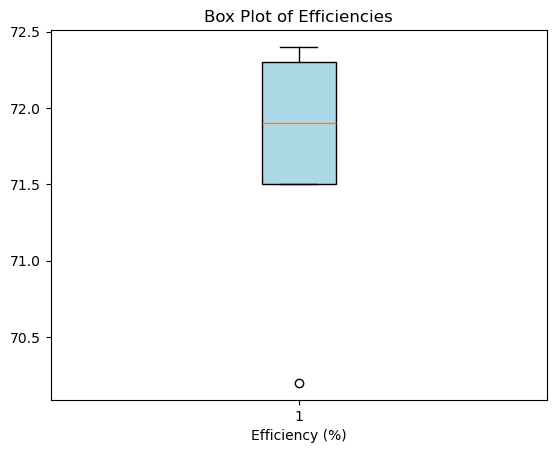

Relevant Data:
Minimum: 70.2
Maximum: 72.4
Mean: 71.66
Median: 71.9
First Quartile (Q1): 71.5
Third Quartile (Q3): 72.3


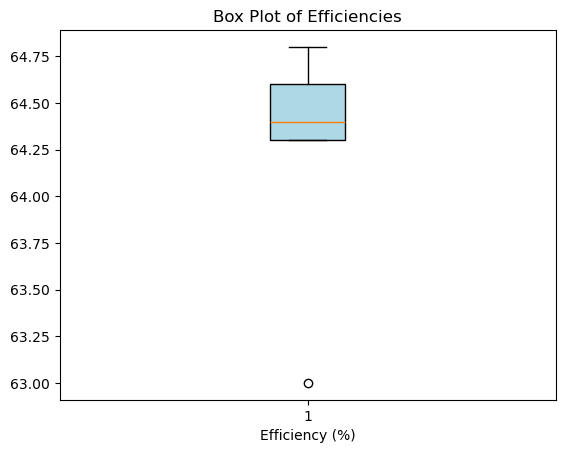

Relevant Data for total electrolyser:
Minimum: 63.0
Maximum: 64.8
Mean: 64.22
Median: 64.4
First Quartile (Q1): 64.3
Third Quartile (Q3): 64.6


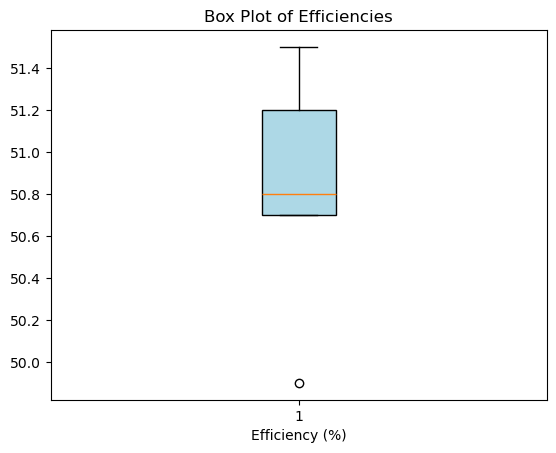

Relevant Data for comp & electrolyser:
Minimum: 49.9
Maximum: 51.5
Mean: 50.82000000000001
Median: 50.8
First Quartile (Q1): 50.7
Third Quartile (Q3): 51.2


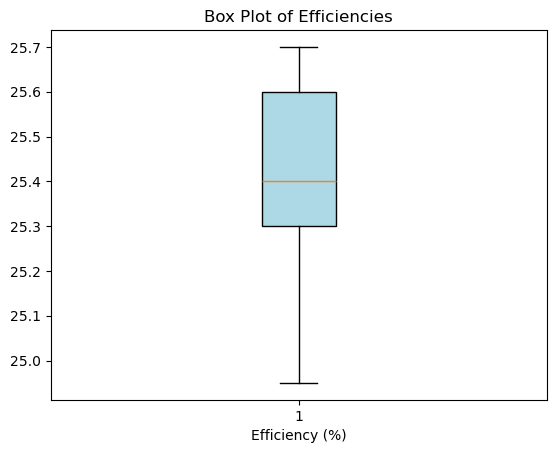

Relevant Data for comp & electrolyser & FC:
Minimum: 24.95
Maximum: 25.7
Mean: 25.389999999999997
Median: 25.4
First Quartile (Q1): 25.3
Third Quartile (Q3): 25.6


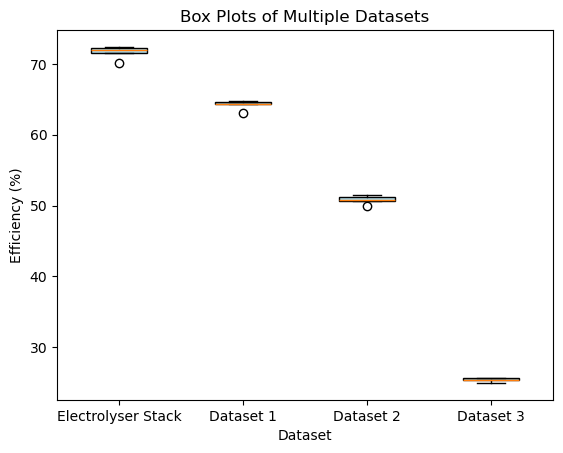

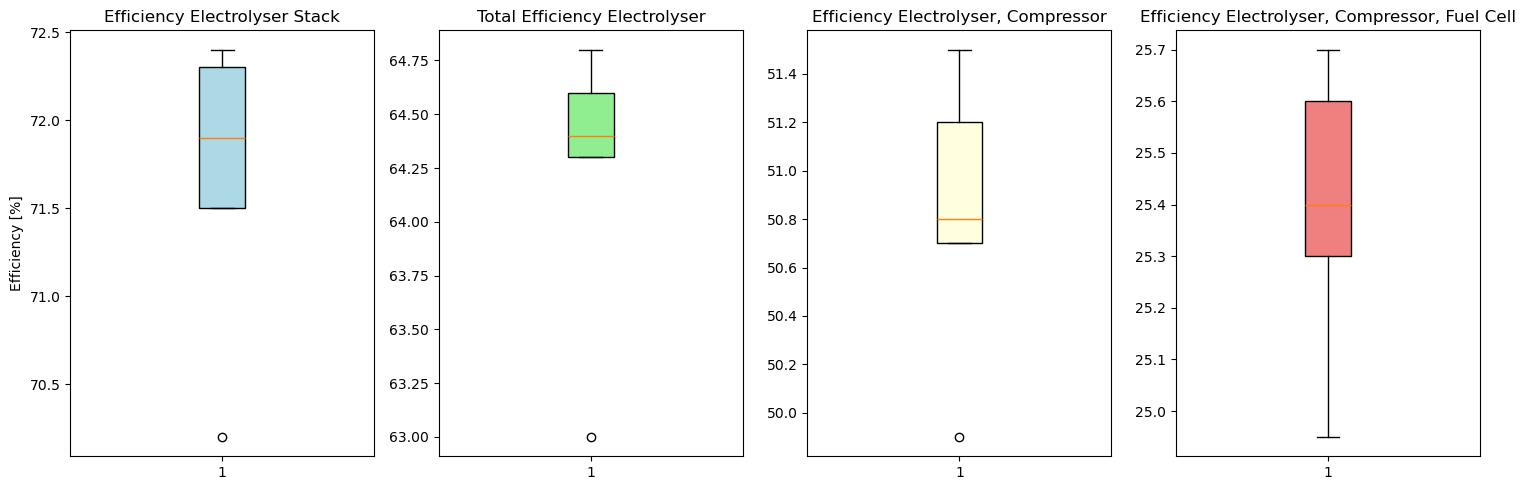

In [79]:

# Electrolyser stack data:
efficienciesSt = [72.3, 72.4, 71.9, 71.5, 70.2]

# Create the box plot
plt.boxplot(efficienciesSt, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of Efficiencies')
plt.xlabel('Efficiency (%)')
plt.show()


# Compute relevant statistics
min_efficiency = np.min(efficienciesSt)
max_efficiency = np.max(efficienciesSt)
mean_efficiency = np.mean(efficienciesSt)
median_efficiency = np.median(efficienciesSt)
q1 = np.percentile(efficienciesSt, 25)  # First quartile
q3 = np.percentile(efficienciesSt, 75)  # Third quartile

# Print relevant data
print("Relevant Data:")
print(f"Minimum: {min_efficiency}")
print(f"Maximum: {max_efficiency}")
print(f"Mean: {mean_efficiency}")
print(f"Median: {median_efficiency}")
print(f"First Quartile (Q1): {q1}")
print(f"Third Quartile (Q3): {q3}")




# Electrolyser total data:
efficienciesEl = [64.3, 64.8, 64.6, 64.4,63.0]

# Create the box plot
plt.boxplot(efficienciesEl, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of Efficiencies')
plt.xlabel('Efficiency (%)')
plt.show()


# Compute relevant statistics
min_efficiency = np.min(efficienciesEl)
max_efficiency = np.max(efficienciesEl)
mean_efficiency = np.mean(efficienciesEl)
median_efficiency = np.median(efficienciesEl)
q1 = np.percentile(efficienciesEl, 25)  # First quartile
q3 = np.percentile(efficienciesEl, 75)  # Third quartile

# Print relevant data
print("Relevant Data for total electrolyser:")
print(f"Minimum: {min_efficiency}")
print(f"Maximum: {max_efficiency}")
print(f"Mean: {mean_efficiency}")
print(f"Median: {median_efficiency}")
print(f"First Quartile (Q1): {q1}")
print(f"Third Quartile (Q3): {q3}")



# Electrolyser & Comp total data:
efficienciesElComp = [49.9,50.7,51.2, 51.5,50.8]

# Create the box plot
plt.boxplot(efficienciesElComp, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of Efficiencies')
plt.xlabel('Efficiency (%)')
plt.show()


# Compute relevant statistics
min_efficiency = np.min(efficienciesElComp)
max_efficiency = np.max(efficienciesElComp)
mean_efficiency = np.mean(efficienciesElComp)
median_efficiency = np.median(efficienciesElComp)
q1 = np.percentile(efficienciesElComp, 25)  # First quartile
q3 = np.percentile(efficienciesElComp, 75)  # Third quartile

# Print relevant data
print("Relevant Data for comp & electrolyser:")
print(f"Minimum: {min_efficiency}")
print(f"Maximum: {max_efficiency}")
print(f"Mean: {mean_efficiency}")
print(f"Median: {median_efficiency}")
print(f"First Quartile (Q1): {q1}")
print(f"Third Quartile (Q3): {q3}")




# Electrolyser & Comp & FC total data:
efficienciesElCompFC = [24.95,25.3,25.6,25.7,25.4]

# Create the box plot
plt.boxplot(efficienciesElCompFC, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of Efficiencies')
plt.xlabel('Efficiency (%)')
plt.show()


# Compute relevant statistics
min_efficiency = np.min(efficienciesElCompFC)
max_efficiency = np.max(efficienciesElCompFC)
mean_efficiency = np.mean(efficienciesElCompFC)
median_efficiency = np.median(efficienciesElCompFC)
q1 = np.percentile(efficienciesElCompFC, 25)  # First quartile
q3 = np.percentile(efficienciesElCompFC, 75)  # Third quartile

# Print relevant data
print("Relevant Data for comp & electrolyser & FC:")
print(f"Minimum: {min_efficiency}")
print(f"Maximum: {max_efficiency}")
print(f"Mean: {mean_efficiency}")
print(f"Median: {median_efficiency}")
print(f"First Quartile (Q1): {q1}")
print(f"Third Quartile (Q3): {q3}")


# Total box plot

# Create the box plot
data = [efficienciesSt, efficienciesEl, efficienciesElComp, efficienciesElCompFC]
plt.boxplot(data, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box Plots of Multiple Datasets')
plt.xlabel('Dataset')
plt.ylabel('Efficiency (%)')
plt.xticks([1, 2, 3, 4], ['Electrolyser Stack','Dataset 1', 'Dataset 2', 'Dataset 3'])  # Label the datasets
plt.show()


# Create subplots
fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharey=False)

# Dataset 1
axes[0].boxplot(efficienciesSt, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Efficiency Electrolyser Stack')
axes[0].set_ylabel('Efficiency [%]')

# Dataset 2
axes[1].boxplot(efficienciesEl, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('Total Efficiency Electrolyser')

# Dataset 3
axes[2].boxplot(efficienciesElComp, patch_artist=True, boxprops=dict(facecolor='lightyellow'))
axes[2].set_title('Efficiency Electrolyser, Compressor')

# Dataset 3
axes[3].boxplot(efficienciesElCompFC, patch_artist=True, boxprops=dict(facecolor='lightcoral'))
axes[3].set_title('Efficiency Electrolyser, Compressor, Fuel Cell')

# Adjust layout
plt.tight_layout()
plt.show()




In [ ]:
df = df.rename(columns={'Electrolyser Power (W)': 'Total Electrolyser Power (W)'})
columns_to_fill = ['Total Electrolyser Power (W)', 'Electrolyser Production Rate (%)', 'Hydrogen Flow Rate (NL/h)','Electrolyser Stack Voltage (V)','Electrolyser Stack Current (A)',]  # Specify your columns here (e.g., 'A', 'B')
df.loc[:df.first_valid_index(), columns_to_fill] = df.loc[:df.first_valid_index(), columns_to_fill].fillna(0)
df.loc[df.last_valid_index() + 1:, columns_to_fill] = df.loc[df.last_valid_index() + 1:, columns_to_fill].fillna(0)

vlines = ['16-07-2024 12:06:47', '16-07-2024 12:08:13', '16-07-2024 12:10:30'] # Start of electrolyser winding up, Electrolyser full power,
vlines = pd.to_datetime(vlines)

df['Hydrogen Flow Rate (NL/h)'] = df['Hydrogen Flow Rate (NL/h)'].interpolate(method='linear')
df['Electrolyser Production Rate (%)'] = df['Electrolyser Production Rate (%)'].interpolate(method='linear')
df['Total Electrolyser Power (W)'] = df['Total Electrolyser Power (W)'].interpolate(method='linear')
df['Electrolyser Stack Voltage (V)'] = df['Electrolyser Stack Voltage (V)'].interpolate(method='linear')
df['Electrolyser Stack Current (A)'] = df['Electrolyser Stack Current (A)'].interpolate(method='linear')
df['Container PV Power (W)'] = df['Container PV Power (W)'].interpolate(method='linear')
df['Electrolyser Power (W)'] = df['Electrolyser Stack Voltage (V)'] * df['Electrolyser Stack Current (A)']


df['Time'] = pd.to_datetime(df['Time'])
start_time = '16-07-2024 12:06:00'  # replace with your start time
end_time = '16-07-2024 12:12:00'    # replace with your end time
df = df[(df['Time'] >= start_time) & (df['Time'] <= end_time)]
    
Time = pd.to_datetime(df['Time'])
time_numeric = (Time - Time.iloc[0]).dt.total_seconds().astype(int)

    
print()
print()
print('----------------------------------------------------------------------------------------------------')
print(f'---------------------------- Electrolyser operating at {name} condition -----------------------------')
print('----------------------------------------------------------------------------------------------------')

    
# Total PV Power over Time
values = df['Container PV Power (W)']
positive_values = np.where(values > 0, values, 0)
TotPVEnergy = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values

plt.figure(figsize=(10, 6))
for vline in vlines:
    plt.axvline(x=vline, color='gray', linestyle='--', label=f'Vertical Line at {vline.strftime("%H:%M:%S")}')
    
plt.fill_between(Time, positive_values, alpha=0.2, label=f'Energy generated (kWh): {TotPVEnergy:.3f}', color='g')
plt.plot(df['Time'], df['Container PV Power (W)'], label='Total PV Power (W)', color='g')
plt.title(f'Total PV Power Over Time, At {name} Condition')
plt.xlabel('Time')
plt.ylabel('Total PV Power (W)')
plt.xlim(df['Time'].min(), df['Time'].max())
plt.ylim(0, df['Container PV Power (W)'].max()*1.2)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig(f"figures/Total PV Power - CloseLook - {name}.png")
plt.show()